In [1]:
import subprocess, sys
for pkg in ['transformers>=4.40','peft>=0.10','bitsandbytes>=0.43','accelerate','datasets']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

import json, os, torch
from pathlib import Path
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
print('✅ Ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 71.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00
✅ Ready


In [ ]:
# ── Kaggle paths ──────────────────────────────────────────────────────
# Update these to match where you uploaded your files on Kaggle
TEST_FILE    = '/kaggle/input/datasets/<<kaggle_username>>/finetuned-models/test.jsonl'
SFT_ADAPTER  = '/kaggle/input/datasets/<<kaggle_username>>/finetuned-models/sft_lora/kaggle/working/sft_lora/checkpoint-300'
DPO_ADAPTER  = '/kaggle/input/datasets/<<kaggle_username>>/finetuned-models/final_adapter/final_adapter'
RESULTS_DIR  = '/kaggle/working/results'
MODEL_NAME   = 'Qwen/Qwen2.5-7B-Instruct'
INSTRUCTION  = 'Extract the key information from the text and return it as JSON.'

os.makedirs(RESULTS_DIR, exist_ok=True)

# Load test set
test_data = []
with open(TEST_FILE, encoding='utf-8') as f:
    for line in f:
        if line.strip():
            test_data.append(json.loads(line))
print(f'Test examples: {len(test_data)}')
# Use first 100 for speed — full eval takes too long on free GPU
eval_data = test_data[:100]


Test examples: 203


In [3]:
from collections import defaultdict

def compute_metrics(predictions, ground_truths):
    """
    predictions:   list of strings (model outputs)
    ground_truths: list of strings (correct JSON from test set)
    Returns dict with all 5 metrics.
    """
    valid_json = exact_match = 0
    field_recall_sum = field_precision_sum = refusal_correct = 0
    refusal_total = 0
    total = len(predictions)

    for pred, truth in zip(predictions, ground_truths):
        truth_dict = json.loads(truth)  # truth is always valid
        is_refusal = (truth_dict == {})

        try:
            pred_dict = json.loads(pred)
            valid_json += 1

            if pred_dict == truth_dict:
                exact_match += 1

            # Field recall
            truth_keys = set(truth_dict.keys())
            pred_keys  = set(pred_dict.keys())
            if truth_keys:
                field_recall_sum += len(truth_keys & pred_keys) / len(truth_keys)

            # Field precision (not hallucinating extra fields)
            if pred_keys:
                field_precision_sum += len(truth_keys & pred_keys) / len(pred_keys)
            else:
                field_precision_sum += 1.0  # empty prediction on refusal = correct

            # Refusal correctness
            if is_refusal:
                refusal_total += 1
                if pred_dict == {}:
                    refusal_correct += 1

        except json.JSONDecodeError:
            pass  # invalid JSON = 0 on all metrics for this example

    return {
        'json_validity_pct':    round(valid_json / total * 100, 1),
        'exact_match_pct':      round(exact_match / total * 100, 1),
        'field_recall_pct':     round(field_recall_sum / total * 100, 1),
        'field_precision_pct':  round(field_precision_sum / total * 100, 1),
        'refusal_correct_pct':  round(refusal_correct / max(1,refusal_total)*100, 1),
        'total_evaluated':      total,
    }

print('✅ Metrics function ready')

✅ Metrics function ready


In [4]:
import os

def run_inference(model, tokenizer, examples, label=''):
    """Run inference on all examples with auto-resume checkpointing."""
    model.eval()
    predictions = []
    
    # 1. Define a checkpoint file specifically for this model
    checkpoint_file = f'{RESULTS_DIR}/{label.lower()}_predictions_checkpoint.json'
    
    # 2. Check if progress already exists and load it
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, 'r', encoding='utf-8') as f:
            predictions = json.load(f)
        print(f"🔄 Resuming [{label}] from checkpoint: {len(predictions)}/{len(examples)} completed.")
    else:
        print(f"🚀 Starting [{label}] inference from scratch...")

    # 3. Figure out where to pick up
    start_idx = len(predictions)
    
    # 4. Process only the remaining examples
    for i in range(start_idx, len(examples)):
        ex = examples[i]
        prompt = ex['input']  
        full_input = (
            f'### Instruction:\n{INSTRUCTION}\n\n'
            f'### Input:\n{prompt}\n\n'
            f'### Response:\n'
        )
        inputs = tokenizer(full_input, return_tensors='pt').to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=200,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        response = tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        ).strip()

        # Extract only the JSON part
        if '{' in response:
            start = response.index('{')
            depth, end = 0, start
            for j, ch in enumerate(response[start:], start):
                if ch == '{': depth += 1
                elif ch == '}': depth -= 1
                if depth == 0: end = j; break
            response = response[start:end+1]

        predictions.append(response)

        # 5. 🔥 SAVE CHECKPOINT AFTER EVERY PREDICTION 🔥
        with open(checkpoint_file, 'w', encoding='utf-8') as f:
            json.dump(predictions, f)

        if (i+1) % 10 == 0:
            print(f'  [{label}] {i+1}/{len(examples)} done')

    return predictions

print('✅ Inference function ready')

✅ Inference function ready


In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print('✅ Tokenizer loaded')

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded


In [6]:
# ── Run this FIRST before loading any adapter ──────────────────────────
print('Loading BASE model (no adapter)...')
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map='auto', trust_remote_code=True,
)
base_model.config.pad_token_id = tokenizer.eos_token_id

print('Running base model inference...')
base_preds  = run_inference(base_model, tokenizer, eval_data, label='BASE')
base_truths = [json.dumps(json.loads(ex['output'])) for ex in eval_data]
base_metrics = compute_metrics(base_preds, base_truths)

print('\n📊 BASE MODEL RESULTS')
print('='*40)
for k,v in base_metrics.items():
    print(f'  {k}: {v}')

# SAVE immediately
with open(f'{RESULTS_DIR}/base_metrics.json','w') as f:
    json.dump(base_metrics, f, indent=2)
print('\n✅ Saved to results/base_metrics.json')

# Free VRAM before loading next model
import gc
del base_model
gc.collect()
torch.cuda.empty_cache()

Loading BASE model (no adapter)...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running base model inference...
🚀 Starting [BASE] inference from scratch...
  [BASE] 10/100 done
  [BASE] 20/100 done
  [BASE] 30/100 done
  [BASE] 40/100 done
  [BASE] 50/100 done
  [BASE] 60/100 done
  [BASE] 70/100 done
  [BASE] 80/100 done
  [BASE] 90/100 done
  [BASE] 100/100 done

📊 BASE MODEL RESULTS
  json_validity_pct: 100.0
  exact_match_pct: 9.0
  field_recall_pct: 51.8
  field_precision_pct: 58.0
  refusal_correct_pct: 50.0
  total_evaluated: 100

✅ Saved to results/base_metrics.json


In [ ]:
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "info"

In [7]:
print('Loading SFT model (checkpoint-303)...')
sft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map='auto', trust_remote_code=True,
)
sft_model = PeftModel.from_pretrained(sft_base, SFT_ADAPTER)
sft_model.config.pad_token_id = tokenizer.eos_token_id

print('Running SFT inference...')
sft_preds   = run_inference(sft_model, tokenizer, eval_data, label='SFT')
sft_metrics = compute_metrics(sft_preds, base_truths)

print('\n📊 SFT MODEL RESULTS')
print('='*40)
for k,v in sft_metrics.items():
    print(f'  {k}: {v}')

with open(f'{RESULTS_DIR}/sft_metrics.json','w') as f:
    json.dump(sft_metrics, f, indent=2)
print('✅ Saved to results/sft_metrics.json')

del sft_model, sft_base
gc.collect(); torch.cuda.empty_cache()

Loading SFT model (checkpoint-303)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


Running SFT inference...
🚀 Starting [SFT] inference from scratch...
  [SFT] 10/100 done
  [SFT] 20/100 done
  [SFT] 30/100 done
  [SFT] 40/100 done
  [SFT] 50/100 done
  [SFT] 60/100 done
  [SFT] 70/100 done
  [SFT] 80/100 done
  [SFT] 90/100 done
  [SFT] 100/100 done

📊 SFT MODEL RESULTS
  json_validity_pct: 100.0
  exact_match_pct: 100.0
  field_recall_pct: 98.0
  field_precision_pct: 100.0
  refusal_correct_pct: 100.0
  total_evaluated: 100
✅ Saved to results/sft_metrics.json


In [8]:
print('Loading DPO model (final_adapter)...')
dpo_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map='auto', trust_remote_code=True,
)
dpo_model = PeftModel.from_pretrained(dpo_base, DPO_ADAPTER)
dpo_model.config.pad_token_id = tokenizer.eos_token_id

print('Running DPO inference...')
dpo_preds   = run_inference(dpo_model, tokenizer, eval_data, label='DPO')
dpo_metrics = compute_metrics(dpo_preds, base_truths)

print('\n📊 DPO MODEL RESULTS')
print('='*40)
for k,v in dpo_metrics.items():
    print(f'  {k}: {v}')

with open(f'{RESULTS_DIR}/dpo_metrics.json','w') as f:
    json.dump(dpo_metrics, f, indent=2)
print('✅ Saved to results/dpo_metrics.json')

Loading DPO model (final_adapter)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


Running DPO inference...
🚀 Starting [DPO] inference from scratch...
  [DPO] 10/100 done
  [DPO] 20/100 done
  [DPO] 30/100 done
  [DPO] 40/100 done
  [DPO] 50/100 done
  [DPO] 60/100 done
  [DPO] 70/100 done
  [DPO] 80/100 done
  [DPO] 90/100 done
  [DPO] 100/100 done

📊 DPO MODEL RESULTS
  json_validity_pct: 100.0
  exact_match_pct: 90.0
  field_recall_pct: 95.6
  field_precision_pct: 97.4
  refusal_correct_pct: 100.0
  total_evaluated: 100
✅ Saved to results/dpo_metrics.json


In [9]:
print('\n' + '='*65)
print('FINAL COMPARISON TABLE — copy this into your README')
print('='*65)
print(f'{"Metric":<28} {"Base":>8} {"SFT":>8} {"DPO":>8}')
print('-'*65)
keys = ['json_validity_pct','exact_match_pct','field_recall_pct',
        'field_precision_pct','refusal_correct_pct']
labels = ['JSON Validity %','Exact Match %','Field Recall %',
          'Field Precision %','Refusal Correct %']
for k, label in zip(keys, labels):
    b = base_metrics.get(k,'N/A')
    s = sft_metrics.get(k,'N/A')
    d = dpo_metrics.get(k,'N/A')
    print(f'{label:<28} {str(b):>7}% {str(s):>7}% {str(d):>7}%')
print('='*65)

# Save combined results
all_results = {
    'base': base_metrics,
    'sft':  sft_metrics,
    'dpo':  dpo_metrics,
}
with open(f'{RESULTS_DIR}/all_metrics.json','w') as f:
    json.dump(all_results, f, indent=2)
print('\n✅ All results saved to /kaggle/working/results/')
print('   Download all_metrics.json and put it in your results/ folder')


FINAL COMPARISON TABLE — copy this into your README
Metric                           Base      SFT      DPO
-----------------------------------------------------------------
JSON Validity %                100.0%   100.0%   100.0%
Exact Match %                    9.0%   100.0%    90.0%
Field Recall %                  51.8%    98.0%    95.6%
Field Precision %               58.0%   100.0%    97.4%
Refusal Correct %               50.0%   100.0%   100.0%

✅ All results saved to /kaggle/working/results/
   Download all_metrics.json and put it in your results/ folder


In [2]:
import os
import shutil
from IPython.display import display, FileLink  # <-- Added 'display' here

# 1. Define the source folder and target zip file paths
source_folder = '/kaggle/working/results'
output_zip = '/kaggle/working/results_download'

# 2. Verify the source folder exists before zipping
if os.path.exists(source_folder):
    print("📦 Compressing folder... Please wait.")
    
    # Creates 'results_download.zip' in /kaggle/working/
    shutil.make_archive(output_zip, 'zip', source_folder)
    
    # <-- FIX: Use a relative path for FileLink to prevent broken links
    zip_file_name = "results_download.zip" 
    
    print(f"✅ Compression complete! File created as: {zip_file_name}")
    
    # 3. Generate a clickable download link in the notebook
    print("\n⬇️ Click the link below to download your folder:")
    display(FileLink(zip_file_name))
    
else:
    print(f"❌ Error: The folder '{source_folder}' does not exist.")
    print("Please check your training output paths.")

📦 Compressing folder... Please wait.
✅ Compression complete! File created as: results_download.zip

⬇️ Click the link below to download your folder:


/kaggle/working/results_download.zip

## Merge LoRA Adapter into Base Model

In [10]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

In [ ]:
MODEL_NAME  = 'Qwen/Qwen2.5-7B-Instruct'
DPO_ADAPTER = '/kaggle/input/datasets/<<kaggle_username>>/finetuned-models/final_adapter/final_adapter'
# PUSH_NAME   = 'your-hf-username/qwen-json-extractor'  # ← change this
PUSH_NAME   = '<<huggingface_username>>/qwen-json-extractor'  # ← change this

# Load base in full precision for merging (needs more VRAM)
print('Loading base model...')
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16,
    # device_map='auto',
    device_map='cpu',
    low_cpu_mem_usage=True,
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Load and merge DPO adapter
print('Merging DPO adapter...')
model = PeftModel.from_pretrained(base, DPO_ADAPTER)
model = model.merge_and_unload()  # this merges LoRA weights into base
print('Merging DPO adapter complited...')

Loading base model...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [ ]:
# Push merged model to Hugging Face Hub
print(f'Pushing to Hub: {PUSH_NAME}')
model.push_to_hub(PUSH_NAME, private=False)
tokenizer.push_to_hub(PUSH_NAME, private=False)
print('✅ Model pushed! Check: https://huggingface.co/' + PUSH_NAME)

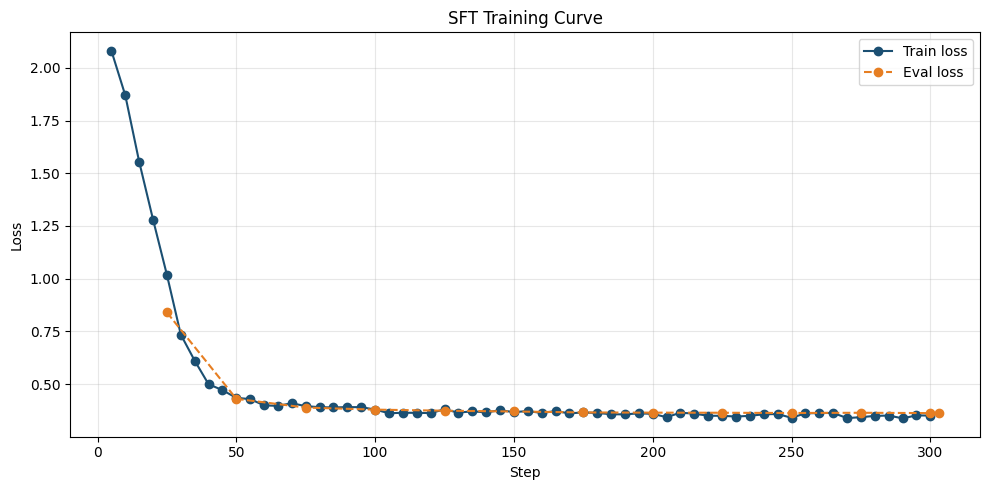

✅ Graph saved! Download /kaggle/working/sft_loss_curve.png


In [ ]:
import matplotlib.pyplot as plt
import json

# 1. Point to your specific checkpoint file
checkpoint = "/kaggle/input/datasets/<<kaggle_username>>/finetuned-models/sft_lora/kaggle/working/sft_lora/checkpoint-303"

# 2. Open the file and load the JSON data
with open(f"{checkpoint}/trainer_state.json", "r") as f:
    state = json.load(f)

logs = state["log_history"]

# 3. Separate Training Loss and Eval Loss
train_loss = [(x['step'], x['loss']) for x in logs if 'loss' in x]
eval_loss  = [(x['step'], x['eval_loss']) for x in logs if 'eval_loss' in x]

# 4. Split coordinates for plotting
steps_t, loss_t = zip(*train_loss) if train_loss else ([],[])
steps_e, loss_e = zip(*eval_loss)  if eval_loss  else ([],[])

# 5. Draw the Graph
plt.figure(figsize=(10, 5))
# Notice the marker='o' added to both lines below:
plt.plot(steps_t, loss_t, label='Train loss', color='#1B4F72', marker='o')
plt.plot(steps_e, loss_e, label='Eval loss', color='#E67E22', linestyle='--', marker='o')

# 6. Format the Graph
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('SFT Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# 7. Save and Display
plt.savefig('/kaggle/working/sft_loss_curve.png', dpi=150)
plt.show()

print('✅ Graph saved! Download /kaggle/working/sft_loss_curve.png')

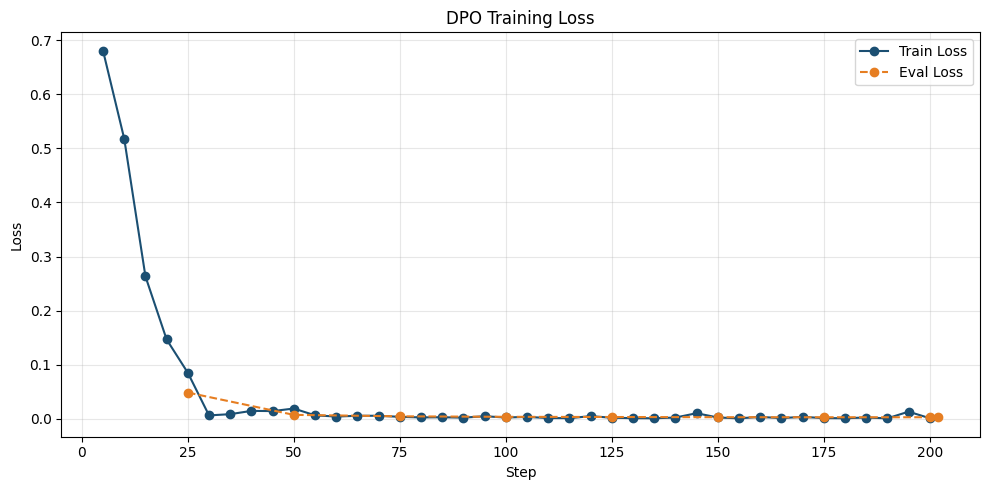

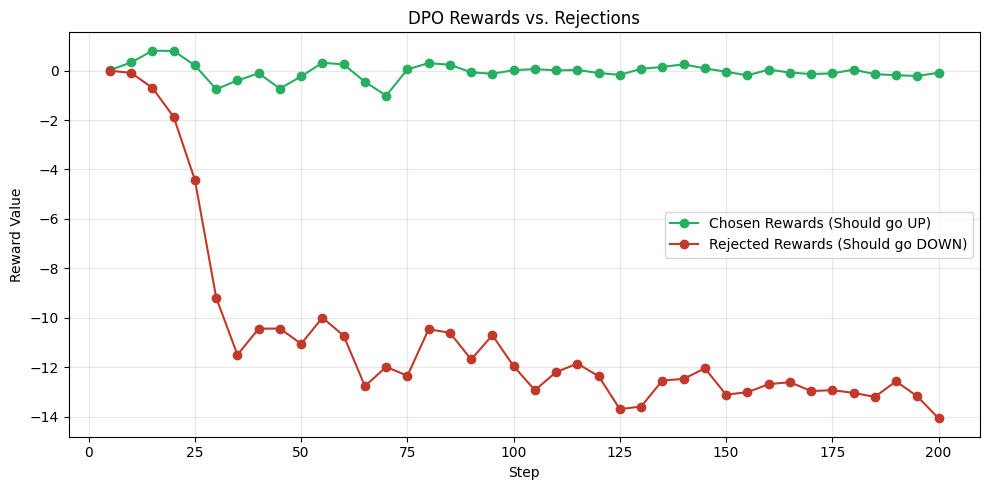

✅ DPO Graphs with dots saved! Download them from the Kaggle output panel.


In [ ]:
import matplotlib.pyplot as plt
import json
import os

# 1. Point to your DPO checkpoint (Update this path!)
dpo_checkpoint = "/kaggle/input/datasets/<<kaggle_username>>/check-dpo/checkpoint-202" 

with open(f"{dpo_checkpoint}/trainer_state.json", "r") as f:
    state = json.load(f)

logs = state["log_history"]

# --- GRAPH 1: DPO LOSS CURVE ---
train_loss = [(x['step'], x['loss']) for x in logs if 'loss' in x]
eval_loss  = [(x['step'], x['eval_loss']) for x in logs if 'eval_loss' in x]

steps_t, loss_t = zip(*train_loss) if train_loss else ([],[])
steps_e, loss_e = zip(*eval_loss)  if eval_loss  else ([],[])

plt.figure(figsize=(10, 5))
# Notice the marker='o' added here to create the dots!
plt.plot(steps_t, loss_t, label='Train Loss', color='#1B4F72', marker='o')
plt.plot(steps_e, loss_e, label='Eval Loss', color='#E67E22', linestyle='--', marker='o')
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('DPO Training Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/dpo_loss_curve.png', dpi=150)
plt.show()

# --- GRAPH 2: DPO REWARDS CURVE ---
rewards_chosen = [(x['step'], x['rewards/chosen']) for x in logs if 'rewards/chosen' in x]
rewards_rejected = [(x['step'], x['rewards/rejected']) for x in logs if 'rewards/rejected' in x]

if rewards_chosen and rewards_rejected:
    steps_rc, vals_rc = zip(*rewards_chosen)
    steps_rr, vals_rr = zip(*rewards_rejected)

    plt.figure(figsize=(10, 5))
    # Marker='o' added here as well!
    plt.plot(steps_rc, vals_rc, label='Chosen Rewards (Should go UP)', color='#27AE60', marker='o')
    plt.plot(steps_rr, vals_rr, label='Rejected Rewards (Should go DOWN)', color='#C0392B', marker='o')
    plt.xlabel('Step'); plt.ylabel('Reward Value')
    plt.title('DPO Rewards vs. Rejections')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/dpo_rewards_curve.png', dpi=150)
    plt.show()
    print('✅ DPO Graphs with dots saved! Download them from the Kaggle output panel.')
else:
    print('✅ DPO Loss Graph saved! (No reward metrics found to plot the second graph).')